In [1]:
%load_ext autoreload
%autoreload 2

import rootutils
root = rootutils.setup_root(search_from=".", indicator=".project-root", pythonpath=True, cwd=True)

In [107]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

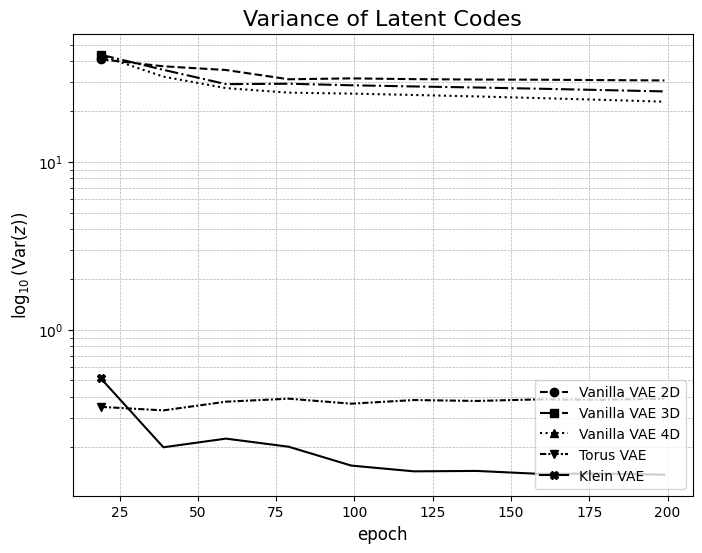

In [120]:
# Load your data
var_z = pd.read_csv("data/ICLR-reports/var_z.csv")

# Define the columns to plot and their corresponding labels
columns_to_plot = [
    "vanilla_vae_2D - var_z", 
    "vanilla_vae_3D - var_z", 
    "vanilla_vae_4D - var_z", 
    "torus_vae - var_z", 
    "klein_vae - var_z"
]
legend_labels = [
    "Vanilla VAE 2D", 
    "Vanilla VAE 3D", 
    "Vanilla VAE 4D", 
    "Torus VAE", 
    "Klein VAE"
]

# Define your custom styles for black-and-white plotting
linestyles = ['--', '-.', ':', (0, (3, 1, 1, 1)), '-']
markers = ['o', 's', '^', 'v', 'X']

# --- Create the Plot using a Matplotlib Loop ---
fig, ax = plt.subplots(figsize=(8, 6))

for i, col in enumerate(columns_to_plot):
    ax.plot(
        var_z["epoch"],
        var_z[col],
        color='black',
        linestyle=linestyles[i],
        marker=markers[i],
        label=legend_labels[i],
        markevery=20,
        markersize=6
    )

# --- Formatting and Corrected Ticks ---
ax.set_title("Variance of Latent Codes", fontsize=16)
ax.set_xlabel("epoch", fontsize=12)
ax.set_ylabel(r"$\log_{10}(\mathrm{Var}(z))$", fontsize=12)
ax.set_yscale('log', base=10)

# Correctly format the log-scale y-axis ticks
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f'$10^{{{int(np.log10(y))}}}$'))

ax.legend(loc='lower right')
ax.grid(True, which="both", linestyle='--', linewidth=0.5)

plt.savefig("notebooks/figures/var_z.png", dpi=300, bbox_inches='tight')
plt.show()

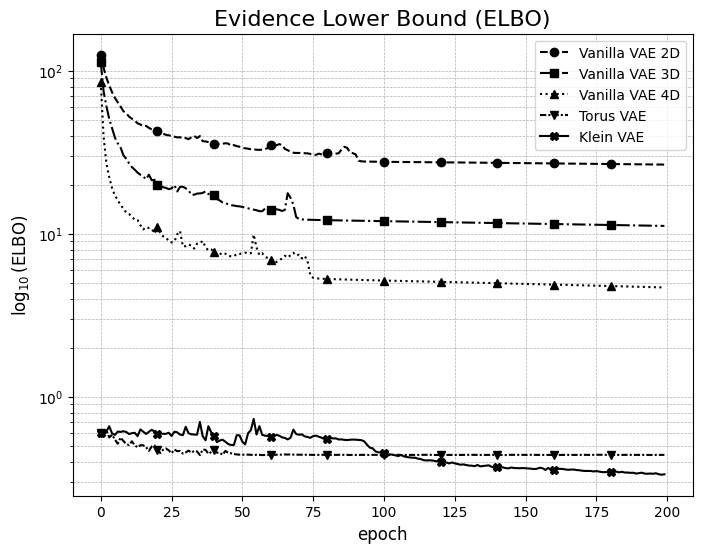

In [121]:
# Load your data
elbo = pd.read_csv("data/ICLR-reports/elbo.csv")

# Define the columns you want to plot
columns_to_plot = [
    "vanilla_vae_2D - val_loss", 
    "vanilla_vae_3D - val_loss", 
    "vanilla_vae_4D - val_loss", 
    "torus_vae - val_loss", 
    "klein_vae - val_loss"
]
# Define the legend labels
legend_labels = [
    "Vanilla VAE 2D", 
    "Vanilla VAE 3D", 
    "Vanilla VAE 4D", 
    "Torus VAE", 
    "Klein VAE"
]

# Define your custom styles for black-and-white plotting 
linestyles = ['--', '-.', ':', (0, (3, 1, 1, 1)), '-'] # Solid, dashed, dash-dot, dotted, custom dash-dot-dot
markers = ['o', 's', '^', 'v', 'X']

# --- Create the Plot using a Matplotlib Loop ---
fig, ax = plt.subplots(figsize=(8, 6))

for i, col in enumerate(columns_to_plot):
    ax.plot(
        elbo["epoch"],
        elbo[col],
        color='black',
        linestyle=linestyles[i],
        marker=markers[i],
        label=legend_labels[i],
        markevery=20,  # Crucial for reducing clutter
        markersize=6
    )

# --- Formatting and Corrected Ticks ---
ax.set_title("Evidence Lower Bound (ELBO)", fontsize=16)
ax.set_xlabel("epoch", fontsize=12)
ax.set_ylabel(r"$\log_{10}$(ELBO)", fontsize=12)
ax.set_yscale('log', base=10)

# Correctly format the log-scale y-axis ticks
# This will show labels like 10^1, 10^2, etc.
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f'$10^{{{int(np.log10(y))}}}$'))

ax.legend(loc='upper right')
ax.grid(True, which="both", linestyle='--', linewidth=0.5)

plt.savefig("notebooks/figures/elbo.png", dpi=300, bbox_inches='tight')
plt.show()

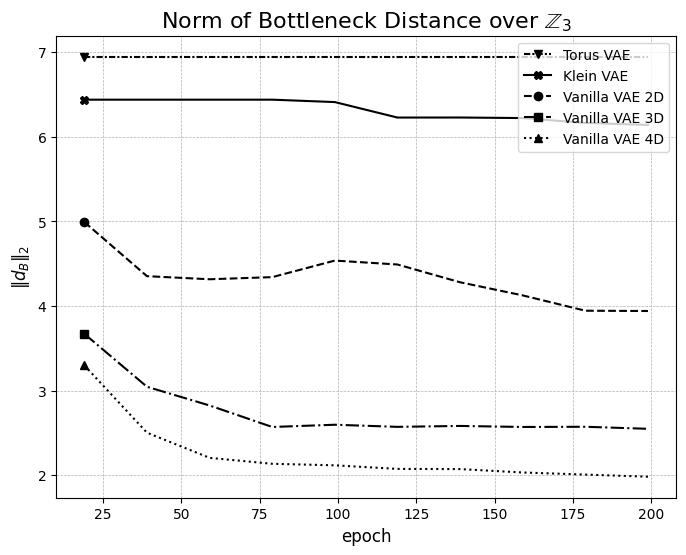

In [122]:
# Load your data
bottleneck_3 = pd.read_csv("data/ICLR-reports/bottleneck_3.csv")

# Define the columns to plot and their corresponding labels
columns_to_plot = [
    "torus_vae - total_bottleneck_over_3", 
    "klein_vae - total_bottleneck_over_3", 
    "vanilla_vae_2D - total_bottleneck_over_3", 
    "vanilla_vae_3D - total_bottleneck_over_3", 
    "vanilla_vae_4D - total_bottleneck_over_3"
]
legend_labels = [
    "Torus VAE", 
    "Klein VAE", 
    "Vanilla VAE 2D", 
    "Vanilla VAE 3D", 
    "Vanilla VAE 4D"
]

# Define your custom styles for black-and-white plotting
linestyles = [(0, (3, 1, 1, 1)), '-', '--', '-.', ':']
markers = ['v', 'X', 'o', 's', '^']

# --- Create the Plot using a Matplotlib Loop ---
fig, ax = plt.subplots(figsize=(8, 6))

for i, col in enumerate(columns_to_plot):
    ax.plot(
        bottleneck_3["epoch"],
        bottleneck_3[col],
        color='black',
        linestyle=linestyles[i],
        marker=markers[i],
        label=legend_labels[i],
        markevery=20,
        markersize=6
    )

# --- Formatting ---
ax.set_title(r"Norm of Bottleneck Distance over $\mathbb{Z}_3$", fontsize=16)
ax.set_xlabel("epoch", fontsize=12)
ax.set_ylabel(r"$\|d_B\|_2$", fontsize=12)

# This formatter is fine for a linear scale, it will display integer tick labels
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f'{int(y)}'))

ax.legend(loc='upper right')
ax.grid(True, which="both", linestyle='--', linewidth=0.5)

# You'll need to add the plt.savefig call here if you want to save the figure
plt.savefig("notebooks/figures/bottleneck_z3.png", dpi=300, bbox_inches='tight')
plt.show()

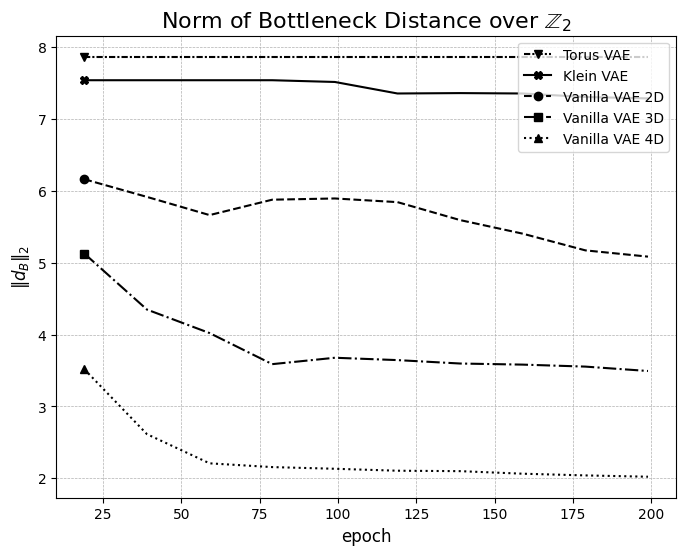

In [123]:
# Load your data
bottleneck_2 = pd.read_csv("data/ICLR-reports/bottleneck_2.csv")

# Define the columns to plot and their corresponding labels
columns_to_plot = [
    "torus_vae - total_bottleneck_over_2", 
    "klein_vae - total_bottleneck_over_2", 
    "vanilla_vae_2D - total_bottleneck_over_2", 
    "vanilla_vae_3D - total_bottleneck_over_2", 
    "vanilla_vae_4D - total_bottleneck_over_2"
]
legend_labels = [
    "Torus VAE", 
    "Klein VAE", 
    "Vanilla VAE 2D", 
    "Vanilla VAE 3D", 
    "Vanilla VAE 4D"
]

# Define your custom styles for black-and-white plotting
linestyles = [(0, (3, 1, 1, 1)), '-', '--', '-.', ':']
markers = ['v', 'X', 'o', 's', '^']

# --- Create the Plot using a Matplotlib Loop ---
fig, ax = plt.subplots(figsize=(8, 6))

for i, col in enumerate(columns_to_plot):
    ax.plot(
        bottleneck_2["epoch"],
        bottleneck_2[col],
        color='black',
        linestyle=linestyles[i],
        marker=markers[i],
        label=legend_labels[i],
        markevery=20,
        markersize=6
    )

# --- Formatting ---
ax.set_title(r"Norm of Bottleneck Distance over $\mathbb{Z}_2$", fontsize=16)
ax.set_xlabel("epoch", fontsize=12)
ax.set_ylabel(r"$\|d_B\|_2$", fontsize=12)

# This formatter is fine for a linear scale, it will display integer tick labels
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f'{int(y)}'))

ax.legend(loc='upper right')
ax.grid(True, which="both", linestyle='--', linewidth=0.5)

# You'll need to add the plt.savefig call here if you want to save the figure
plt.savefig("notebooks/figures/bottleneck_z2.png", dpi=300, bbox_inches='tight')
plt.show()